<a href="https://colab.research.google.com/github/TaimoorAbdullah/KNN/blob/Update/knn.update.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns
from sklearn import datasets

In [ ]:
%cd /content/drive/MyDrive/Course Material/Supervised Machine Learning/KNN

/content/drive/MyDrive/Course Material/Supervised Machine Learning/KNN


In [ ]:
data  =  pd.read_csv('titanic_train.csv')
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
data.drop(['Ticket','Cabin','Name'],axis   = 1,inplace  =   True)
data

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,0,0,13.0000,S
887,888,1,1,female,19.0,0,0,30.0000,S
888,889,0,3,female,NaN,1,2,23.4500,S
889,890,1,1,male,26.0,0,0,30.0000,C


In [ ]:
data.isnull().any()

,0
PassengerId,False
Survived,False
Pclass,False
Sex,False
Age,True
SibSp,False
Parch,False
Fare,False
Embarked,True


In [ ]:
data.Age.fillna(value = data.Age.mean(),inplace = True)
data.Embarked.dropna(inplace = True)
data.isnull().any()

/tmp/ipykernel_860/3811662523.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data.Age.fillna(value = data.Age.mean(),inplace = True)


,0
PassengerId,False
Survived,False
Pclass,False
Sex,False
Age,False
SibSp,False
Parch,False
Fare,False
Embarked,True


In [ ]:
dumies1 = pd.get_dummies(data['Sex'],drop_first = True)
dumies2 =  pd.get_dummies(data['Embarked'])
data_new  = pd.concat([data,dumies1,dumies2],axis  =1)
data_new.drop(['Sex','Embarked'],axis   = 1, inplace  =  True)

In [ ]:
data_new

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,male,C,Q,S
0,1,0,3,22.000000,1,0,7.2500,True,False,False,True
1,2,1,1,38.000000,1,0,71.2833,False,True,False,False
2,3,1,3,26.000000,0,0,7.9250,False,False,False,True
3,4,1,1,35.000000,1,0,53.1000,False,False,False,True
4,5,0,3,35.000000,0,0,8.0500,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,27.000000,0,0,13.0000,True,False,False,True
887,888,1,1,19.000000,0,0,30.0000,False,False,False,True
888,889,0,3,29.699118,1,2,23.4500,False,False,False,True
889,890,1,1,26.000000,0,0,30.0000,True,True,False,False


In [ ]:
x =data_new.drop(['Survived'],axis =1 ).values

y = data_new['Survived'].values
#x

In [ ]:
x_train,x_test,y_train,y_test  =  train_test_split(x,y,test_size  =  0.2, random_state  =  42)
from sklearn.preprocessing import StandardScaler
sc  =  StandardScaler()
x_train  =  sc.fit_transform(x_train)
x_test = sc.transform(x_test)
error_rate  =[]
for i in range (1,50):
  knn= KNeighborsClassifier(n_neighbors  =  i)
  knn.fit(x_train,y_train)
  prediction  =  knn.predict(x_test)
  accuracy  =  np.mean(prediction ==y_test)
  error_rate_values  =  1 - accuracy
  error_rate.append(error_rate_values)

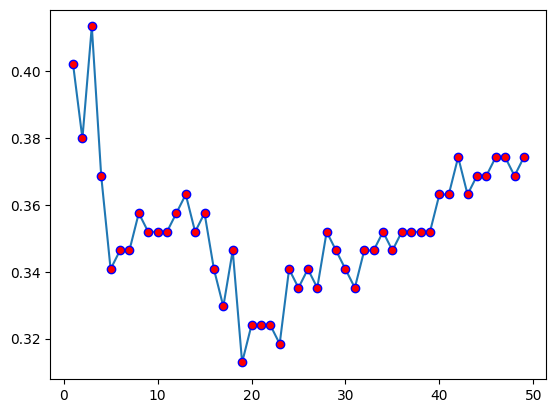

In [ ]:
plt.plot(range(1,50),error_rate,marker = 'o',markerfacecolor  ='red',markeredgecolor = 'blue',lw  =  1.5)

In [ ]:
knn_1    = KNeighborsClassifier(n_neighbors  =  19)
knn_1.fit(x_train,y_train)
prediction_1  =  knn_1.predict(x_test)
accuracy_1 = np.mean(prediction_1==y_test)
accuracy_1

np.float64(0.8100558659217877)